Phase 1

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import os
from tqdm import tqdm

# --- 1. Load the Latent Embeddings ---
print("Loading 2D Latent Embeddings...")
pangu_data = np.load('/home/teoaivalis/floods_kg/reanalysis_data/journal_files/ablation_sudies/pangu_embeddings_3d.npy', allow_pickle=True).item()
era5_data = np.load('/home/teoaivalis/floods_kg/reanalysis_data/journal_files/ablation_sudies/era5_embeddings_3d.npy', allow_pickle=True).item()

Loading 2D Latent Embeddings...


In [2]:
# --- 2. ID Normalization Logic ---
# To ensure Pangu forecasts match the Graph Database IDs exactly
def normalize_id(folder_name):
    """Converts F_2022_... or FL_2022_... consistently to FL_..."""
    parts = folder_name.split('_')
    # Grab the Year, ID, and Country Code
    core_id = "_".join(parts[-3:])
    return f"FL_{core_id}"

# Build a lookup table for ERA5 (Matrix formulation for fast computation)
era5_keys = list(era5_data.keys())
era5_norm_ids = [normalize_id(k) for k in era5_keys]
era5_matrix = np.array([era5_data[k] for k in era5_keys])

print(f"Loaded {len(pangu_data)} Pangu Queries and {len(era5_matrix)} Historical ERA5 Database Events.")

Loaded 237 Pangu Queries and 1242 Historical ERA5 Database Events.


In [3]:
# --- 3. Create Output Directory ---
OUTPUT_DIR = "final_results_3d_p1"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
# --- 4. The Search Engine (Cosine Similarity) ---
print("\nExecuting similarity search against historical database...")

for pangu_key, pangu_vector in tqdm(pangu_data.items(), desc="Scoring Pangu Forecasts"):
    query_id = normalize_id(pangu_key)
    query_vector = pangu_vector.reshape(1, -1)
    
    # 1. Calculate Cosine Similarity against the ENTIRE historical database at once
    # Result is an array of scores from -1.0 to 1.0
    similarities = cosine_similarity(query_vector, era5_matrix)[0]
    
    # 2. Build a DataFrame of the results
    df_results = pd.DataFrame({
        'Historical_Disaster_ID': era5_norm_ids,
        'CNN_Cosine_Similarity': similarities
    })
    
    # 3. Drop the exact same event if it exists (Optional, but good for backtesting)
    # If Pangu is predicting the 2021 Nepal flood, we might want to exclude the actual 
    # 2021 Nepal flood from the 'historical' matches to see what ELSE is similar.
    df_results = df_results[df_results['Historical_Disaster_ID'] != query_id]
    
    # 4. Sort by highest similarity
    df_results = df_results.sort_values(by='CNN_Cosine_Similarity', ascending=False).reset_index(drop=True)
    
    # 5. Save the results (Top 100 matches) into a dedicated folder for the Dual Engine
    event_dir = os.path.join(OUTPUT_DIR, query_id)
    os.makedirs(event_dir, exist_ok=True)
    
    csv_path = os.path.join(event_dir, "cnn_bayesian_results.csv") # Naming convention from your notebook!
    df_results.to_csv(csv_path, index=False)

print(f"\nPhase 1 Complete! Ranked lists saved to '{OUTPUT_DIR}' directory.")


Executing similarity search against historical database...


Scoring Pangu Forecasts: 100%|██████████| 237/237 [00:02<00:00, 86.97it/s]


Phase 1 Complete! Ranked lists saved to 'final_results_3d_p1' directory.


Phase 2

In [6]:
import pandas as pd

# Load the KG extract
df_kg = pd.read_csv("graph_embeddings/extracted_disaster_embeddings_P1.csv")

print("--- Data Structure ---")
print(df_kg.info())

print("\n--- First 10 Disaster Names in Neo4j ---")
for name in df_kg['DisasterName'].head(10):
    print(f"'{name}'")

print("\n--- Checking for Hyphens vs Underscores ---")
sample_name = str(df_kg['DisasterName'].iloc[0])
if "-" in sample_name:
    print("Result: Neo4j uses HYPHENS (-)")
elif "_" in sample_name:
    print("Result: Neo4j uses UNDERSCORES (_)")
else:
    print("Result: Neither found. Check format manually.")

--- Data Structure ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1592 entries, 0 to 1591
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DisasterName     1592 non-null   object 
 1   RegionName       1592 non-null   object 
 2   Embedding        1592 non-null   object 
 3   tsne_Component1  1592 non-null   float64
 4   tsne_Component2  1592 non-null   float64
dtypes: float64(2), object(3)
memory usage: 62.3+ KB
None

--- First 10 Disaster Names in Neo4j ---
'FL-2008-000035-PRY'
'FL-2023-000217-PRY'
'Paraguay: Floods - Jun 1995'
'FL-2018-000419-PRY'
'FL-2012-000056-PRY'
'FL-2014-000030-PRY'
'FL-1997-000299-PRY'
'FL-2019-000033-PRY'
'name=Paraguay: Floods - Mar 1995'
'FL-2013-000076-PRY'

--- Checking for Hyphens vs Underscores ---
Result: Neo4j uses HYPHENS (-)


In [7]:
import os
import json
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

# --- Configuration ---
RESULTS_DIR = "final_results_3d_p1"
KG_EMBEDDINGS_FILE = "graph_embeddings/extracted_disaster_embeddings_P1.csv"

# Paper Formula Parameters: 
# Alpha_j = S_lat * (1.0 + (W / (k + R_dom)))
K_CUSTOM = 5    
W_CUSTOM = 1.0  
k_DECAY = 10    

In [8]:
# --- 1. Load Knowledge Graph Data ---
print("Loading Neo4j Knowledge Graph Embeddings...")
df_kg = pd.read_csv(KG_EMBEDDINGS_FILE)

# Parse the JSON string back into a numpy array
df_kg['Embedding'] = df_kg['Embedding'].apply(lambda x: np.array(json.loads(x)))

# --- 1B. THE FIX: Normalize Knowledge Graph IDs to match CNN (Underscores) ---
def normalize_kg_name(name):
    # 1. Remove "name=" if it exists
    clean_name = str(name).replace("name=", "")
    # 2. Replace hyphens with underscores so FL-2019-000062-SSD becomes FL_2019_000062_SSD
    clean_name = clean_name.replace("-", "_")
    return clean_name.strip()

# Build the lookup dictionary using the normalized names
kg_dict = {}
for _, row in df_kg.iterrows():
    norm_id = normalize_kg_name(row['DisasterName'])
    kg_dict[norm_id] = row['Embedding']

kg_ids = list(kg_dict.keys())
kg_matrix = np.array([kg_dict[eid] for eid in kg_ids])

print(f"Loaded {len(kg_ids)} historical graph embeddings.")

Loading Neo4j Knowledge Graph Embeddings...
Loaded 1520 historical graph embeddings.


In [9]:
# --- 2. Execute Asymmetric Fusion Pipeline ---
pangu_folders = [f for f in os.listdir(RESULTS_DIR) if os.path.isdir(os.path.join(RESULTS_DIR, f))]

for folder in tqdm(pangu_folders, desc="Executing Dual-Engine Fusion"):
    cnn_csv_path = os.path.join(RESULTS_DIR, folder, "cnn_bayesian_results.csv")
    
    if not os.path.exists(cnn_csv_path):
        continue
        
    df_cnn = pd.read_csv(cnn_csv_path)
    
    # --- Step 2A: Build the Proxy Graph Query ---
    proxy_vectors = []
    weights = []
    
    # Check against our newly normalized kg_dict keys
    top_k_matches = df_cnn[df_cnn['Historical_Disaster_ID'].isin(kg_dict)].head(K_CUSTOM)
    
    for _, row in top_k_matches.iterrows():
        hist_id = row['Historical_Disaster_ID']
        cnn_score = row['CNN_Cosine_Similarity']
        
        proxy_vectors.append(kg_dict[hist_id] * cnn_score)
        weights.append(cnn_score)
        
    if not proxy_vectors:
        print(f"\n[Warning] Still no graph matches found for {folder}. It might genuinely not exist in Neo4j.")
        continue
        
    proxy_query = np.sum(proxy_vectors, axis=0) / np.sum(weights)
    proxy_query = proxy_query.reshape(1, -1)
    
    # --- Step 2B: Calculate Graph Similarities ---
    graph_similarities = cosine_similarity(proxy_query, kg_matrix)[0]
    
    df_graph = pd.DataFrame({
        'Historical_Disaster_ID': kg_ids,
        'Graph_Cosine_Similarity': graph_similarities
    })
    
    df_graph['Domain_Rank'] = df_graph['Graph_Cosine_Similarity'].rank(ascending=False, method='min')
    
    graph_csv_path = os.path.join(RESULTS_DIR, folder, "graph_bayesian_results.csv")
    df_graph.to_csv(graph_csv_path, index=False)
    
    # --- Step 2C: Final Asymmetric Fusion ---
    df_fused = pd.merge(df_cnn, df_graph, on='Historical_Disaster_ID', how='inner')
    
    # Formula: Alpha_j = S_lat * (1.0 + (W / (k + R_dom)))
    df_fused['Boost_Factor'] = 1.0 + (W_CUSTOM / (k_DECAY + df_fused['Domain_Rank']))
    df_fused['Final_Alpha_Weight'] = df_fused['CNN_Cosine_Similarity'] * df_fused['Boost_Factor']
    
    df_fused = df_fused.sort_values(by='Final_Alpha_Weight', ascending=False).reset_index(drop=True)
    
    fused_csv_path = os.path.join(RESULTS_DIR, folder, "final_bayesian_attribution.csv")
    df_fused.to_csv(fused_csv_path, index=False)

print("\nPhase 2 Complete! Dual Engine Fusion rankings generated.")

Executing Dual-Engine Fusion: 100%|██████████| 237/237 [00:07<00:00, 30.32it/s]


Phase 2 Complete! Dual Engine Fusion rankings generated.


Here we evaluate the different rankings

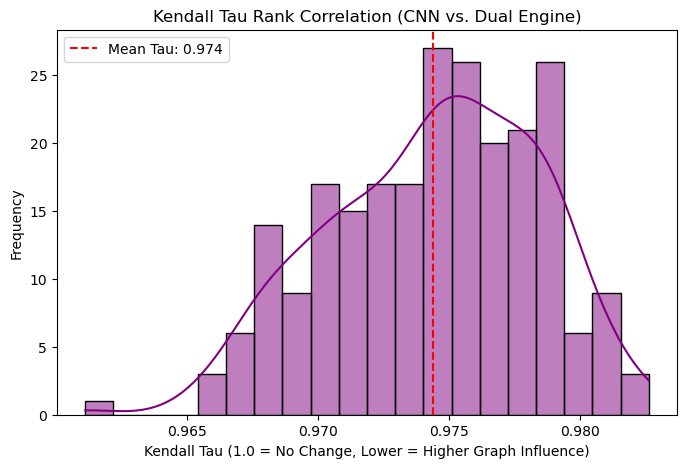

Average Kendall Tau: 0.9744
Conclusion: A score below 0.9 confirms the Knowledge Graph successfully restructured the attribution rankings based on domain topology!


In [10]:
import os
import pandas as pd
import numpy as np
from scipy.stats import kendalltau
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = "final_results_3d_p1"

tau_scores = []
folders = [f for f in os.listdir(RESULTS_DIR) if os.path.isdir(os.path.join(RESULTS_DIR, f))]

for folder in folders:
    cnn_path = os.path.join(RESULTS_DIR, folder, "cnn_bayesian_results.csv")
    fused_path = os.path.join(RESULTS_DIR, folder, "final_bayesian_attribution.csv")
    
    if os.path.exists(cnn_path) and os.path.exists(fused_path):
        df_cnn = pd.read_csv(cnn_path)
        df_fused = pd.read_csv(fused_path)
        
        # Ensure we are comparing the exact same set of historical events
        common_ids = set(df_cnn['Historical_Disaster_ID']).intersection(set(df_fused['Historical_Disaster_ID']))
        
        if len(common_ids) < 2:
            continue
            
        # Get the rank order for the common events
        df_cnn_common = df_cnn[df_cnn['Historical_Disaster_ID'].isin(common_ids)].set_index('Historical_Disaster_ID')
        df_fused_common = df_fused[df_fused['Historical_Disaster_ID'].isin(common_ids)].set_index('Historical_Disaster_ID')
        
        # Align them so the order matches for scipy
        df_fused_common = df_fused_common.reindex(df_cnn_common.index)
        
        # Calculate Kendall Tau (-1 to 1)
        # We rank them by their scores
        rank_cnn = df_cnn_common['CNN_Cosine_Similarity'].rank(ascending=False)
        rank_fused = df_fused_common['Final_Alpha_Weight'].rank(ascending=False)
        
        tau, p_val = kendalltau(rank_cnn, rank_fused)
        if not np.isnan(tau):
            tau_scores.append(tau)

# Plot the distribution of rank shifts
plt.figure(figsize=(8, 5))
sns.histplot(tau_scores, bins=20, kde=True, color='purple')
plt.axvline(np.mean(tau_scores), color='red', linestyle='dashed', label=f'Mean Tau: {np.mean(tau_scores):.3f}')
plt.title("Kendall Tau Rank Correlation (CNN vs. Dual Engine)")
plt.xlabel("Kendall Tau (1.0 = No Change, Lower = Higher Graph Influence)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(f"Average Kendall Tau: {np.mean(tau_scores):.4f}")
print("Conclusion: A score below 0.9 confirms the Knowledge Graph successfully restructured the attribution rankings based on domain topology!")

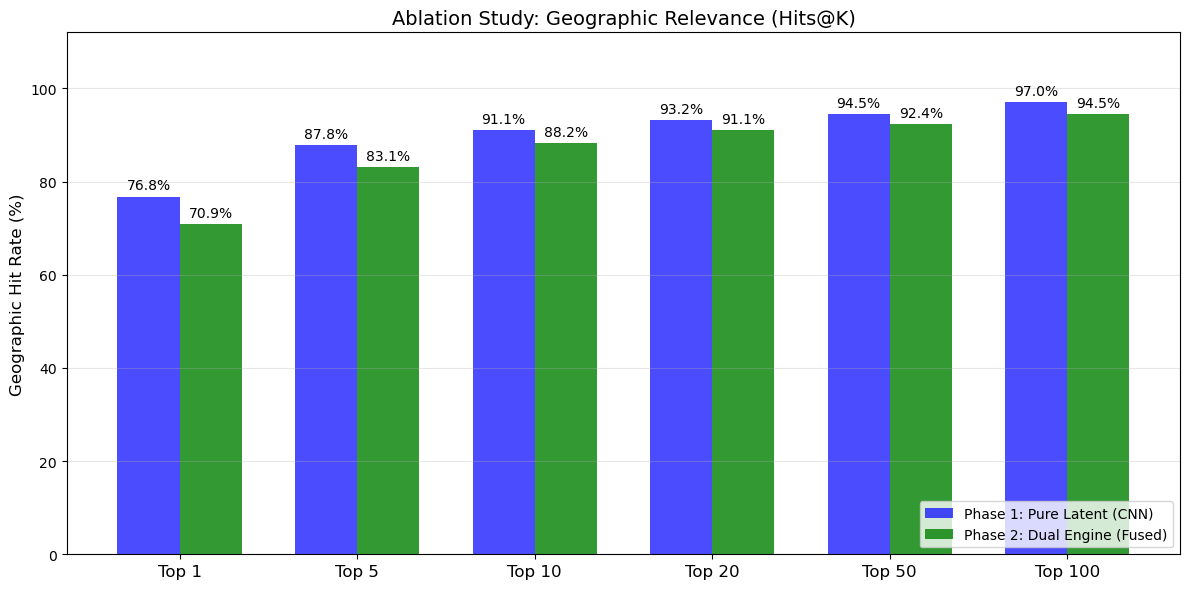

Total Queries Evaluated: 237


In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = "final_results_3d_p1"

def extract_country_code(disaster_id):
    # Extracts 'COL' from 'FL_2012_000042_COL'
    return str(disaster_id).split('_')[-1].strip()

# Expanded Metrics tracking
cnn_hits = {'Top_1': 0, 'Top_5': 0, 'Top_10': 0, 'Top_20': 0, 'Top_50': 0, 'Top_100': 0}
fused_hits = {'Top_1': 0, 'Top_5': 0, 'Top_10': 0, 'Top_20': 0, 'Top_50': 0, 'Top_100': 0}
total_queries = 0

folders = [f for f in os.listdir(RESULTS_DIR) if os.path.isdir(os.path.join(RESULTS_DIR, f))]

for folder in folders:
    cnn_path = os.path.join(RESULTS_DIR, folder, "cnn_bayesian_results.csv")
    fused_path = os.path.join(RESULTS_DIR, folder, "final_bayesian_attribution.csv")
    
    if not (os.path.exists(cnn_path) and os.path.exists(fused_path)):
        continue
        
    df_cnn = pd.read_csv(cnn_path)
    df_fused = pd.read_csv(fused_path)
    
    # What country is the Pangu forecast for?
    query_country = extract_country_code(folder)
    total_queries += 1
    
    # --- Check pure CNN Accuracy (Extract top 100 instead of 10) ---
    cnn_top_100 = [extract_country_code(x) for x in df_cnn['Historical_Disaster_ID'].head(100)]
    
    if len(cnn_top_100) > 0 and query_country == cnn_top_100[0]: cnn_hits['Top_1'] += 1
    if query_country in cnn_top_100[:5]:   cnn_hits['Top_5'] += 1
    if query_country in cnn_top_100[:10]:  cnn_hits['Top_10'] += 1
    if query_country in cnn_top_100[:20]:  cnn_hits['Top_20'] += 1
    if query_country in cnn_top_100[:50]:  cnn_hits['Top_50'] += 1
    if query_country in cnn_top_100[:100]: cnn_hits['Top_100'] += 1
        
    # --- Check Fused Dual Engine Accuracy (Extract top 100 instead of 10) ---
    fused_top_100 = [extract_country_code(x) for x in df_fused['Historical_Disaster_ID'].head(100)]
    
    if len(fused_top_100) > 0 and query_country == fused_top_100[0]: fused_hits['Top_1'] += 1
    if query_country in fused_top_100[:5]:   fused_hits['Top_5'] += 1
    if query_country in fused_top_100[:10]:  fused_hits['Top_10'] += 1
    if query_country in fused_top_100[:20]:  fused_hits['Top_20'] += 1
    if query_country in fused_top_100[:50]:  fused_hits['Top_50'] += 1
    if query_country in fused_top_100[:100]: fused_hits['Top_100'] += 1

# --- Plot the Comparison ---
labels = ['Top 1', 'Top 5', 'Top 10', 'Top 20', 'Top 50', 'Top 100']
keys = ['Top_1', 'Top_5', 'Top_10', 'Top_20', 'Top_50', 'Top_100']

# Convert to percentages
cnn_rates = [cnn_hits[k]/total_queries * 100 for k in keys]
fused_rates = [fused_hits[k]/total_queries * 100 for k in keys]

x = np.arange(len(labels))
width = 0.35

# Made the figure slightly wider (12, 6) to fit 6 categories comfortably
fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, cnn_rates, width, label='Phase 1: Pure Latent (CNN)', color='blue', alpha=0.7)
rects2 = ax.bar(x + width/2, fused_rates, width, label='Phase 2: Dual Engine (Fused)', color='green', alpha=0.8)

ax.set_ylabel('Geographic Hit Rate (%)', fontsize=12)
ax.set_title('Ablation Study: Geographic Relevance (Hits@K)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.legend(loc='lower right') # Moved legend so it doesn't block the Top 100 bars

# Add values on top of bars
ax.bar_label(rects1, fmt='%.1f%%', padding=3, fontsize=10)
ax.bar_label(rects2, fmt='%.1f%%', padding=3, fontsize=10)

# Set Y axis dynamically based on the max value so labels aren't cut off
plt.ylim(0, max(max(cnn_rates), max(fused_rates)) + 15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total Queries Evaluated: {total_queries}")

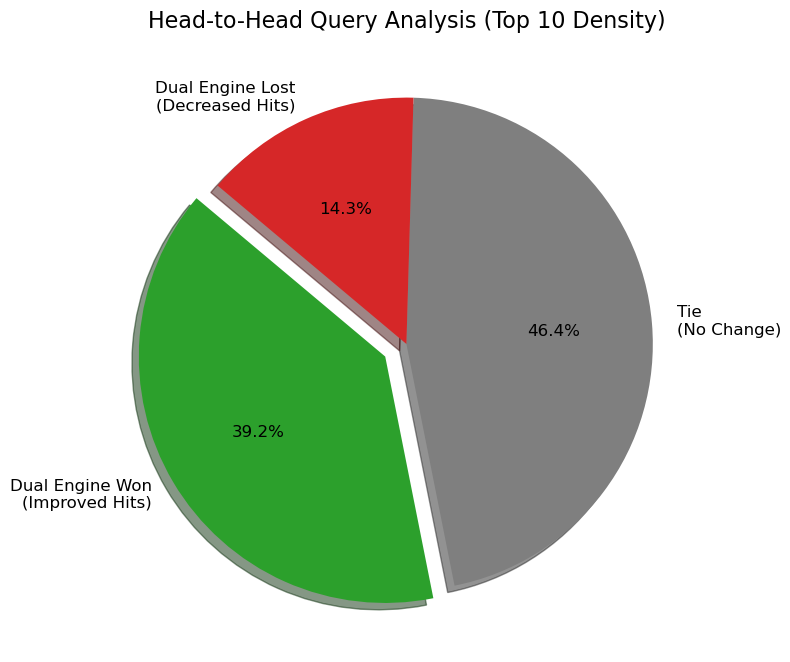

Total Queries Evaluated: 237
Wins: 93 | Ties: 110 | Losses: 34

🏆 BIGGEST WINS (Graph Engine fixed the CNN's blindness):
          Query_ID Query_Country  CNN_Hits  Fused_Hits  Net_Change
FL_2018_000413_IND           IND         4           9           5
FL_2022_000316_NER           NER         3           7           4
FL_2020_000132_UGA           UGA         2           6           4
FL_2021_000126_MYS           MYS         3           7           4
FL_2020_000006_IRN           IRN         3           7           4


🚨 CATASTROPHIC FAILURES (Graph Engine destroyed a good CNN score):
          Query_ID Query_Country  CNN_Hits  Fused_Hits  Net_Change
FL_2018_000158_TUN           TUN         4           1          -3
FL_2020_000204_TUN           TUN         4           1          -3
FL_2022_000190_TUN           TUN         3           0          -3
FL_2022_000265_YEM           YEM         5           3          -2
FL_2018_000112_GEO           GEO         6           4          -2
FL_201

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = "final_results_3d_p1"
K_TARGET = 10  # Let's focus our deep-dive on the Top 10 window

def extract_country_code(disaster_id):
    return str(disaster_id).split('_')[-1].strip()

folders = [f for f in os.listdir(RESULTS_DIR) if os.path.isdir(os.path.join(RESULTS_DIR, f))]

# Tracking lists
wins = 0
ties = 0
losses = 0
query_stats = []

for folder in folders:
    cnn_path = os.path.join(RESULTS_DIR, folder, "cnn_bayesian_results.csv")
    fused_path = os.path.join(RESULTS_DIR, folder, "final_bayesian_attribution.csv")
    
    if not (os.path.exists(cnn_path) and os.path.exists(fused_path)):
        continue
        
    df_cnn = pd.read_csv(cnn_path)
    df_fused = pd.read_csv(fused_path)
    
    query_country = extract_country_code(folder)
    
    # Extract Top 10 countries
    cnn_top_10 = [extract_country_code(x) for x in df_cnn['Historical_Disaster_ID'].head(K_TARGET)]
    fused_top_10 = [extract_country_code(x) for x in df_fused['Historical_Disaster_ID'].head(K_TARGET)]
    
    # Count hits
    cnn_hits = sum(1 for c in cnn_top_10 if c == query_country)
    fused_hits = sum(1 for c in fused_top_10 if c == query_country)
    
    # Calculate difference
    diff = fused_hits - cnn_hits
    
    if diff > 0: wins += 1
    elif diff == 0: ties += 1
    else: losses += 1
        
    query_stats.append({
        'Query_ID': folder,
        'Query_Country': query_country,
        'CNN_Hits': cnn_hits,
        'Fused_Hits': fused_hits,
        'Net_Change': diff
    })

# Convert to DataFrame for easy sorting
df_stats = pd.DataFrame(query_stats)

# --- 1. Plotting the Win/Tie/Loss Distribution ---
labels = ['Dual Engine Won\n(Improved Hits)', 'Tie\n(No Change)', 'Dual Engine Lost\n(Decreased Hits)']
sizes = [wins, ties, losses]
colors = ['#2ca02c', '#7f7f7f', '#d62728'] # Green, Gray, Red
explode = (0.1, 0, 0)  

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
       shadow=True, startangle=140, textprops={'fontsize': 12})
ax.set_title(f"Head-to-Head Query Analysis (Top {K_TARGET} Density)", fontsize=16)
plt.show()

# --- 2. Identifying the Outliers ---
print(f"Total Queries Evaluated: {len(df_stats)}")
print(f"Wins: {wins} | Ties: {ties} | Losses: {losses}\n")

# Find the biggest winners (where the graph helped the most)
biggest_winners = df_stats.sort_values(by='Net_Change', ascending=False).head(5)
print("🏆 BIGGEST WINS (Graph Engine fixed the CNN's blindness):")
print(biggest_winners.to_string(index=False))
print("\n" + "="*60 + "\n")

# Find the catastrophic failures (where the graph destroyed the CNN)
biggest_losers = df_stats.sort_values(by='Net_Change', ascending=True).head(10)
print("🚨 CATASTROPHIC FAILURES (Graph Engine destroyed a good CNN score):")
print(biggest_losers.to_string(index=False))

EXport_country

In [ ]:
MATCH (d:Disaster)-[:hasCountry]->(r:Region)
WHERE d.name IS NOT NULL
RETURN 
    d.name AS Event_id, 
    r.name AS Country

Export_Bio

In [ ]:
MATCH (r:Region)
// We use the exact relationship names from your schema to pull in all ecological data
OPTIONAL MATCH (r)-[:hasBiodiversity|hasLandCover|hasMorphologicalZone|hasMorphology]->(eco)
WHERE eco.name IS NOT NULL
// Format them as 'category: [Name],' so your Python regex parser can read them
WITH r, collect(DISTINCT "category: " + eco.name + ",") AS categories
RETURN 
    "name: " + r.name + "," AS region_metadata,
    reduce(s = "", cat IN categories | s + cat + " ") AS biodiversity_data

In [13]:
import os
import pandas as pd
import numpy as np
import re
import collections
import math

RESULTS_DIR = 'final_results_3d_p1' 
K_TARGET = 10

# --- 1. Load Taxonomic and Country Data ---
raw_bio_df = pd.read_csv('export_bio.csv')
events_df = pd.read_csv('export_country.csv')

# Clean and map events to countries
event_to_country = {}
for _, row in events_df.iterrows():
    clean_id = str(row['Event_id']).replace("name=", "").replace("_", "-").strip()
    event_to_country[clean_id] = str(row['Country']).strip()

def extract_categories(s):
    if pd.isna(s) or s == '[]': return []
    return [match.strip() for match in re.findall(r'category:\s*([^,]+),', str(s))]

def extract_country_name(s):
    if pd.isna(s): return 'Unknown'
    match = re.search(r'name:\s*([^,]+),', str(s))
    return match.group(1).strip() if match else 'Unknown'

def build_taxonomic_profile(category_list):
    if not category_list: return {}
    counts = collections.Counter(category_list)
    return {cat: count / sum(counts.values()) for cat, count in counts.items()}

country_profiles = {}
for _, row in raw_bio_df.iterrows():
    c_name = extract_country_name(row['region_metadata'])
    if c_name != 'Unknown':
        country_profiles[c_name] = build_taxonomic_profile(extract_categories(row['biodiversity_data']))

def calculate_taxonomic_sim(country1, country2):
    """Calculates cosine similarity between two country taxonomic profiles."""
    if country1 not in country_profiles or country2 not in country_profiles: 
        return np.nan # Missing data
    p1, p2 = country_profiles[country1], country_profiles[country2]
    all_cats = set(p1.keys()).union(set(p2.keys()))
    v1, v2 = [p1.get(c, 0.0) for c in all_cats], [p2.get(c, 0.0) for c in all_cats]
    norm = math.sqrt(sum(a*a for a in v1)) * math.sqrt(sum(b*b for b in v2))
    return sum(a*b for a, b in zip(v1, v2)) / norm if norm > 0 else 0.0

def extract_country_code(disaster_id):
    return str(disaster_id).split('_')[-1].strip()

# --- 2. Evaluate the "Promoted" vs "Demoted" Events in Losses ---
folders = [f for f in os.listdir(RESULTS_DIR) if os.path.isdir(os.path.join(RESULTS_DIR, f))]
loss_stats = []

missing_data_count = 0

for folder in folders:
    cnn_path = os.path.join(RESULTS_DIR, folder, "cnn_bayesian_results.csv")
    fused_path = os.path.join(RESULTS_DIR, folder, "final_bayesian_attribution.csv")
    if not (os.path.exists(cnn_path) and os.path.exists(fused_path)): continue
        
    df_cnn = pd.read_csv(cnn_path)
    df_fused = pd.read_csv(fused_path)
    
    query_country_code = extract_country_code(folder)
    
    cnn_top_10_ids = df_cnn['Historical_Disaster_ID'].head(K_TARGET).tolist()
    fused_top_10_ids = df_fused['Historical_Disaster_ID'].head(K_TARGET).tolist()
    
    cnn_hits = sum(1 for x in cnn_top_10_ids if extract_country_code(x) == query_country_code)
    fused_hits = sum(1 for x in fused_top_10_ids if extract_country_code(x) == query_country_code)
    
    # Analyze the "Losses"
    if fused_hits < cnn_hits:
        demoted_ids = set(cnn_top_10_ids) - set(fused_top_10_ids)
        promoted_ids = set(fused_top_10_ids) - set(cnn_top_10_ids)
        
        query_event_id = folder.replace('_', '-')
        query_country_name = event_to_country.get(query_event_id)
        
        if not query_country_name: 
            continue
            
        # Calculate Average Taxonomic Sim for Demoted (CNN's choice)
        demoted_sims = []
        for d_id in demoted_ids:
            c_name = event_to_country.get(d_id.replace('_', '-'))
            sim = calculate_taxonomic_sim(query_country_name, c_name)
            if not np.isnan(sim): demoted_sims.append(sim)
            else: missing_data_count += 1
                
        # Calculate Average Taxonomic Sim for Promoted (Graph's choice)
        promoted_sims = []
        for p_id in promoted_ids:
            c_name = event_to_country.get(p_id.replace('_', '-'))
            sim = calculate_taxonomic_sim(query_country_name, c_name)
            if not np.isnan(sim): promoted_sims.append(sim)
            else: missing_data_count += 1
                
        # ONLY skip if BOTH lists are completely empty
        if not demoted_sims and not promoted_sims:
            continue
            
        avg_demoted = np.mean(demoted_sims) if demoted_sims else 0.0
        avg_promoted = np.mean(promoted_sims) if promoted_sims else 0.0
        
        loss_stats.append({
            'Query': folder,
            'Query_Country': query_country_name,
            'CNN_Lost_Events_Tax_Sim': avg_demoted,
            'Graph_Promoted_Events_Tax_Sim': avg_promoted,
            'Net_Ecological_Gain': avg_promoted - avg_demoted
        })

# --- 3. Display Results ---
df_loss = pd.DataFrame(loss_stats)

print(f"Ignored {missing_data_count} specific historical events due to missing Neo4j taxonomic data.")
print(f"Successfully Analyzed {len(df_loss)} 'Loss' queries.\n")

if len(df_loss) > 0:
    print(f"Average Taxonomic Sim of events the CNN wanted: {df_loss['CNN_Lost_Events_Tax_Sim'].mean()*100:.1f}%")
    print(f"Average Taxonomic Sim of events the Graph promoted: {df_loss['Graph_Promoted_Events_Tax_Sim'].mean()*100:.1f}%\n")

    positive_gains = len(df_loss[df_loss['Net_Ecological_Gain'] > 0])
    print(f"In {positive_gains} out of {len(df_loss)} 'Losses', the Knowledge Graph actually INCREASED ecological similarity!")

    print("\n--- TOP 10 ECOLOGICAL RECOVERIES (Graph fixed CNN's cross-country errors) ---")
    best_recoveries = df_loss.sort_values(by='Net_Ecological_Gain', ascending=False).head(10)
    for _, row in best_recoveries.iterrows():
        print(f"Query: {row['Query']} ({row['Query_Country']})")
        print(f"  -> CNN chose events with {row['CNN_Lost_Events_Tax_Sim']*100:.1f}% taxonomic similarity.")
        print(f"  -> Graph swapped them for events with {row['Graph_Promoted_Events_Tax_Sim']*100:.1f}% similarity! (Gain: +{row['Net_Ecological_Gain']*100:.1f}%)")
        print("-" * 60)

Ignored 42 specific historical events due to missing Neo4j taxonomic data.
Successfully Analyzed 22 'Loss' queries.

Average Taxonomic Sim of events the CNN wanted: 22.5%
Average Taxonomic Sim of events the Graph promoted: 59.4%

In 17 out of 22 'Losses', the Knowledge Graph actually INCREASED ecological similarity!

--- TOP 10 ECOLOGICAL RECOVERIES (Graph fixed CNN's cross-country errors) ---
Query: FL_2022_000292_LAO (Lao People's Democratic Republic the)
  -> CNN chose events with 0.0% taxonomic similarity.
  -> Graph swapped them for events with 76.7% similarity! (Gain: +76.7%)
------------------------------------------------------------
Query: FL_2021_000110_YEM (Yemen)
  -> CNN chose events with 0.0% taxonomic similarity.
  -> Graph swapped them for events with 73.1% similarity! (Gain: +73.1%)
------------------------------------------------------------
Query: FL_2018_000144_PRK (Democratic People's Republic of Korea)
  -> CNN chose events with 0.0% taxonomic similarity.
  -> Gra

In [1]:
import os
import pandas as pd
import numpy as np
import re
import collections
import math

RESULTS_DIR = 'final_results_3d_p1' 
K_TARGET = 10

# --- 1. Load Taxonomic and Country Data ---
raw_bio_df = pd.read_csv('export_bio.csv')
events_df = pd.read_csv('export_country.csv')

# Clean and map events to countries
event_to_country = {}
for _, row in events_df.iterrows():
    clean_id = str(row['Event_id']).replace("name=", "").replace("_", "-").strip()
    event_to_country[clean_id] = str(row['Country']).strip()

def extract_categories(s):
    if pd.isna(s) or s == '[]': return []
    return [match.strip() for match in re.findall(r'category:\s*([^,]+),', str(s))]

def extract_country_name(s):
    if pd.isna(s): return 'Unknown'
    match = re.search(r'name:\s*([^,]+),', str(s))
    return match.group(1).strip() if match else 'Unknown'

def build_taxonomic_profile(category_list):
    if not category_list: return {}
    counts = collections.Counter(category_list)
    return {cat: count / sum(counts.values()) for cat, count in counts.items()}

country_profiles = {}
for _, row in raw_bio_df.iterrows():
    c_name = extract_country_name(row['region_metadata'])
    if c_name != 'Unknown':
        country_profiles[c_name] = build_taxonomic_profile(extract_categories(row['biodiversity_data']))

def calculate_taxonomic_sim(country1, country2):
    if country1 not in country_profiles or country2 not in country_profiles: 
        return np.nan 
    p1, p2 = country_profiles[country1], country_profiles[country2]
    all_cats = set(p1.keys()).union(set(p2.keys()))
    v1, v2 = [p1.get(c, 0.0) for c in all_cats], [p2.get(c, 0.0) for c in all_cats]
    norm = math.sqrt(sum(a*a for a in v1)) * math.sqrt(sum(b*b for b in v2))
    return sum(a*b for a, b in zip(v1, v2)) / norm if norm > 0 else 0.0

def extract_country_code(disaster_id):
    return str(disaster_id).split('_')[-1].strip()

# --- 2. Evaluate the "Promoted" vs "Demoted" Events in WINS ---
folders = [f for f in os.listdir(RESULTS_DIR) if os.path.isdir(os.path.join(RESULTS_DIR, f))]
win_stats = []

missing_data_count = 0

for folder in folders:
    cnn_path = os.path.join(RESULTS_DIR, folder, "cnn_bayesian_results.csv")
    fused_path = os.path.join(RESULTS_DIR, folder, "final_bayesian_attribution.csv")
    if not (os.path.exists(cnn_path) and os.path.exists(fused_path)): continue
        
    df_cnn = pd.read_csv(cnn_path)
    df_fused = pd.read_csv(fused_path)
    
    query_country_code = extract_country_code(folder)
    
    cnn_top_10_ids = df_cnn['Historical_Disaster_ID'].head(K_TARGET).tolist()
    fused_top_10_ids = df_fused['Historical_Disaster_ID'].head(K_TARGET).tolist()
    
    cnn_hits = sum(1 for x in cnn_top_10_ids if extract_country_code(x) == query_country_code)
    fused_hits = sum(1 for x in fused_top_10_ids if extract_country_code(x) == query_country_code)
    
    # Analyze the "WINS" (Graph improved geographic hits)
    if fused_hits > cnn_hits:
        demoted_ids = set(cnn_top_10_ids) - set(fused_top_10_ids)
        promoted_ids = set(fused_top_10_ids) - set(cnn_top_10_ids)
        
        query_event_id = folder.replace('_', '-')
        query_country_name = event_to_country.get(query_event_id)
        
        if not query_country_name: 
            continue
            
        # Calculate Average Taxonomic Sim for events the CNN liked but Graph dropped
        demoted_sims = []
        for d_id in demoted_ids:
            c_name = event_to_country.get(d_id.replace('_', '-'))
            sim = calculate_taxonomic_sim(query_country_name, c_name)
            if not np.isnan(sim): demoted_sims.append(sim)
            else: missing_data_count += 1
                
        # Calculate Average Taxonomic Sim for events the Graph promoted into Top 10
        promoted_sims = []
        for p_id in promoted_ids:
            c_name = event_to_country.get(p_id.replace('_', '-'))
            sim = calculate_taxonomic_sim(query_country_name, c_name)
            if not np.isnan(sim): promoted_sims.append(sim)
            else: missing_data_count += 1
                
        if not demoted_sims and not promoted_sims:
            continue
            
        avg_demoted = np.mean(demoted_sims) if demoted_sims else 0.0
        avg_promoted = np.mean(promoted_sims) if promoted_sims else 0.0
        
        win_stats.append({
            'Query': folder,
            'Query_Country': query_country_name,
            'CNN_Demoted_Sim': avg_demoted,
            'Graph_Promoted_Sim': avg_promoted,
            'Net_Ecological_Gain': avg_promoted - avg_demoted
        })

# --- 3. Display Results ---
df_win = pd.DataFrame(win_stats)

print(f"Successfully Analyzed {len(df_win)} 'Win' queries.\n")

if len(df_win) > 0:
    print(f"Average Taxonomic Sim of bad events the Graph KICKED OUT: {df_win['CNN_Demoted_Sim'].mean()*100:.1f}%")
    print(f"Average Taxonomic Sim of good events the Graph BROUGHT IN: {df_win['Graph_Promoted_Sim'].mean()*100:.1f}%\n")

    positive_gains = len(df_win[df_win['Net_Ecological_Gain'] > 0])
    print(f"In {positive_gains} out of {len(df_win)} 'Wins', the Knowledge Graph INCREASED ecological similarity while ALSO fixing geography!")

    print("\n--- TOP 10 DOUBLE WINS (Graph fixed Geography AND Ecology) ---")
    best_wins = df_win.sort_values(by='Net_Ecological_Gain', ascending=False).head(10)
    for _, row in best_wins.iterrows():
        print(f"Query: {row['Query']} ({row['Query_Country']})")
        print(f"  -> CNN liked events with {row['CNN_Demoted_Sim']*100:.1f}% sim.")
        print(f"  -> Graph swapped them for events with {row['Graph_Promoted_Sim']*100:.1f}% sim! (Gain: +{row['Net_Ecological_Gain']*100:.1f}%)")
        print("-" * 60)

Successfully Analyzed 84 'Win' queries.

Average Taxonomic Sim of bad events the Graph KICKED OUT: 44.5%
Average Taxonomic Sim of good events the Graph BROUGHT IN: 86.7%

In 77 out of 84 'Wins', the Knowledge Graph INCREASED ecological similarity while ALSO fixing geography!

--- TOP 10 DOUBLE WINS (Graph fixed Geography AND Ecology) ---
Query: FL_2022_000217_BGD (Bangladesh)
  -> CNN liked events with 0.0% sim.
  -> Graph swapped them for events with 100.0% sim! (Gain: +100.0%)
------------------------------------------------------------
Query: FL_2020_000237_LKA (Sri Lanka)
  -> CNN liked events with 0.0% sim.
  -> Graph swapped them for events with 100.0% sim! (Gain: +100.0%)
------------------------------------------------------------
Query: FL_2018_000425_LKA (Sri Lanka)
  -> CNN liked events with 0.0% sim.
  -> Graph swapped them for events with 100.0% sim! (Gain: +100.0%)
------------------------------------------------------------
Query: FL_2020_000029_TZA (United Republic of T

🌍 TOP 15 CROSS-BORDER ENVIRONMENTAL BIOMES DISCOVERED BY THE GRAPH 🌍
These countries are repeatedly linked together by the 3D-P5 model:

India <---> Serbia : 17 strong links
Laos <---> Thailand : 13 strong links
Georgia <---> Nepal : 12 strong links
Bangladesh <---> Madagascar : 12 strong links
Mali <---> Sudan : 11 strong links
Afghanistan <---> Trinidad and Tobago : 11 strong links
Benin <---> Senegal : 10 strong links
Bangladesh <---> South Africa : 9 strong links
Bosnia and Herzegovina <---> Nepal : 9 strong links
Haiti <---> Yemen : 8 strong links
Mauritania <---> Chad : 8 strong links
Nicaragua <---> Tunisia : 8 strong links
Sudan <---> South Sudan : 8 strong links
El Salvador <---> Zambia : 8 strong links
Congo <---> Indonesia : 8 strong links


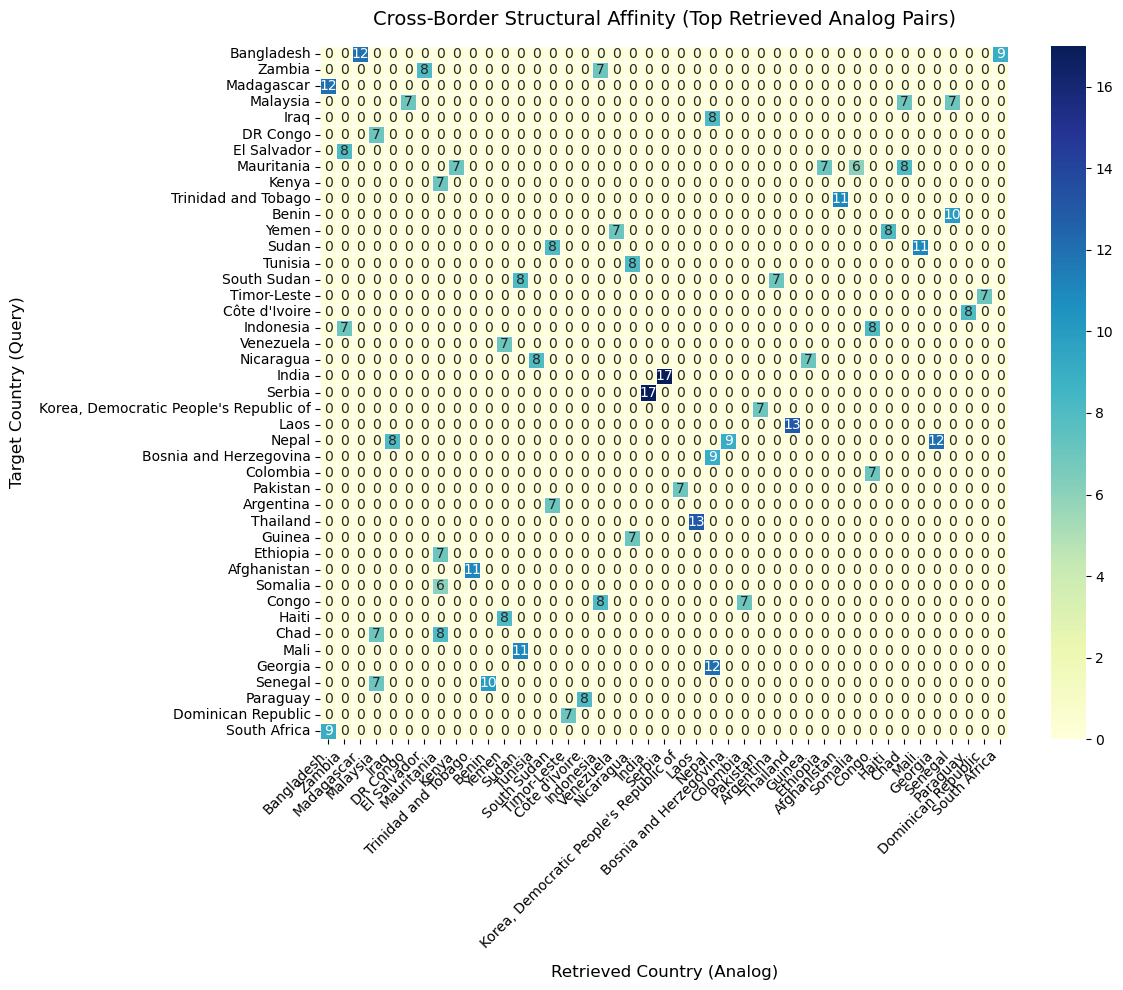

In [2]:
import os
import pandas as pd
import numpy as np
import collections
import matplotlib.pyplot as plt
import seaborn as sns
import pycountry

RESULTS_DIR = "final_results_3d_p1"
K_TARGET = 10

def extract_country_code(disaster_id):
    return str(disaster_id).split('_')[-1].strip()

def get_full_country_name(iso3_code):
    """Converts a 3-letter ISO code to the full country name."""
    try:
        country = pycountry.countries.get(alpha_3=iso3_code)
        if country:
            # Shorten a few exceptionally long official names for better formatting
            if iso3_code == 'LAO': return "Laos"
            if iso3_code == 'COD': return "DR Congo"
            if iso3_code == 'VEN': return "Venezuela"
            if iso3_code == 'BOL': return "Bolivia"
            if iso3_code == 'IRN': return "Iran"
            return country.name
        return iso3_code
    except Exception:
        return iso3_code

# List to store all cross-border pairs: (Target_Country, Retrieved_Country)
cross_border_links = []

folders = [f for f in os.listdir(RESULTS_DIR) if os.path.isdir(os.path.join(RESULTS_DIR, f))]

for folder in folders:
    fused_path = os.path.join(RESULTS_DIR, folder, "final_bayesian_attribution.csv")
    
    if not os.path.exists(fused_path):
        continue
        
    df_fused = pd.read_csv(fused_path)
    query_country = extract_country_code(folder)
    
    # Get top 10 retrieved countries
    fused_top_10 = [extract_country_code(x) for x in df_fused['Historical_Disaster_ID'].head(K_TARGET)]
    
    # Record every time it fetches a DIFFERENT country
    for retrieved_country in fused_top_10:
        if retrieved_country != query_country:
            # Sort them alphabetically so (A, B) and (B, A) are treated as the same structural link
            pair = tuple(sorted([query_country, retrieved_country]))
            cross_border_links.append(pair)

# Count the most frequent pairs
pair_counts = collections.Counter(cross_border_links)

print("🌍 TOP 15 CROSS-BORDER ENVIRONMENTAL BIOMES DISCOVERED BY THE GRAPH 🌍")
print("These countries are repeatedly linked together by the 3D-P5 model:\n")
for pair, count in pair_counts.most_common(15):
    c1_name = get_full_country_name(pair[0])
    c2_name = get_full_country_name(pair[1])
    print(f"{c1_name} <---> {c2_name} : {count} strong links")

# ==========================================
# Create a Heatmap for the Paper
# ==========================================

# Get the top 20 most active countries in these pairs to keep the heatmap readable
top_pairs = pair_counts.most_common(30)
active_countries = set()
for pair, _ in top_pairs:
    active_countries.add(pair[0])
    active_countries.add(pair[1])
active_countries = list(active_countries)

# Create an empty matrix using the full names as labels
active_country_names = [get_full_country_name(c) for c in active_countries]
matrix = pd.DataFrame(0, index=active_country_names, columns=active_country_names)

# Populate the matrix
for pair, count in top_pairs:
    c1_name = get_full_country_name(pair[0])
    c2_name = get_full_country_name(pair[1])
    matrix.at[c1_name, c2_name] = count
    matrix.at[c2_name, c1_name] = count # Make it symmetric

plt.figure(figsize=(12, 10)) # Made slightly larger to accommodate full names
sns.heatmap(matrix, cmap="YlGnBu", annot=True, fmt="d", linewidths=.5)
plt.title("Cross-Border Structural Affinity (Top Retrieved Analog Pairs)", fontsize=14, pad=15)
plt.xlabel("Retrieved Country (Analog)", fontsize=12, labelpad=10)
plt.ylabel("Target Country (Query)", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right') # Rotate x-axis names so they don't overlap
plt.tight_layout()
plt.show()